# Video: Building an Image Classification Model Using LeNet

In [50]:
# Building an Image Classification Model Using LeNet

import os
from PIL import Image

# Define the paths
path = r'/content/drive/MyDrive/Building your first AI Agent with LangGraph/Computer Vision using PyTorch/Module 2/Human Action Recognition'
folder = 'train'
activity = 'cycling'
img_name = 'Image_93.jpg'

# Construct the full image path
img_path = os.path.join(path, folder, activity, img_name)

# Open and display the image
image = Image.open(img_path)
image.show()

print(image.size)
print(image.mode)


(385, 131)
RGB


In [51]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [52]:
# Define transformations for the training and validation sets
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])


In [53]:
# Paths to the data
train_data_path = r'/content/drive/MyDrive/Building your first AI Agent with LangGraph/Computer Vision using PyTorch/Module 2/Human Action Recognition/train'
test_data_path = r'/content/drive/MyDrive/Building your first AI Agent with LangGraph/Computer Vision using PyTorch/Module 2/Human Action Recognition/test'


In [54]:
# Apply the transforms to the train and test data
train_data = datasets.ImageFolder(root=train_data_path, transform=transform)
test_data = datasets.ImageFolder(root=test_data_path, transform=transform)

In [55]:
print(train_data.classes)
num_classes = len(train_data.classes)
print(num_classes)

['cycling', 'dancing', 'drinking', 'eating', 'sitting']
5


Counter({'sitting': 714, 'drinking': 714, 'cycling': 714, 'eating': 714, 'dancing': 714})


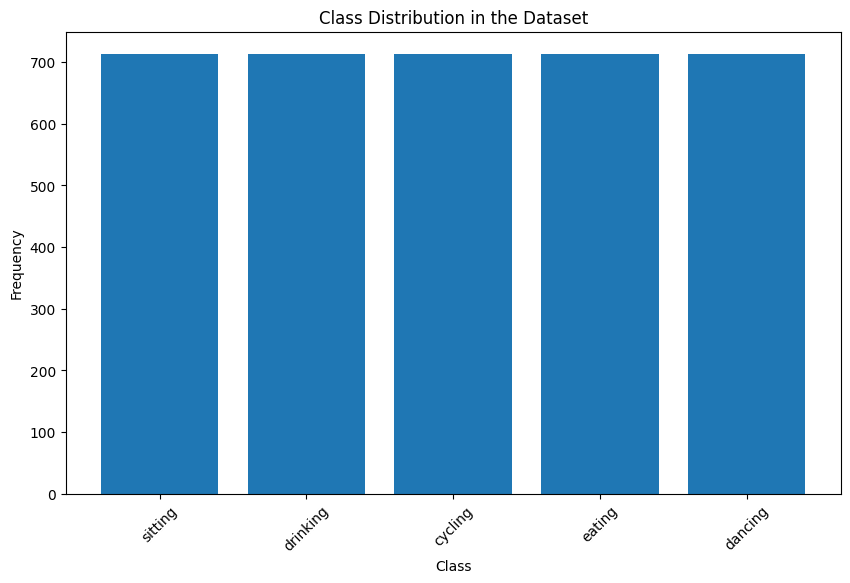

In [56]:
from collections import Counter
import matplotlib.pyplot as plt

# Checking class distribution
class_distribution = Counter([label for label in os.listdir(train_data_path) if os.path.isdir(os.path.join(train_data_path, label))])

# Get the count of images in each class
for label in class_distribution:
    class_distribution[label] = len(os.listdir(os.path.join(train_data_path, label)))

# Print the class distribution
print(class_distribution)

# Plotting the class distribution
plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Distribution in the Dataset')
plt.xticks(rotation=45)  # Rotate class labels for better readability
plt.show()


### LeNet Architecture

In [57]:
# Define LeNet-5 model
class LeNet5(nn.Module):
    def __init__(self, num_classes=num_classes):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = torch.nn.functional.relu(self.conv1(x))
        x = torch.nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.nn.functional.relu(self.conv2(x))
        x = torch.nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.flatten(x, 1)
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [58]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [59]:
device

device(type='cuda')

In [60]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [61]:
# Initialize LeNet-5 model
model = LeNet5().to(device)

In [62]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [63]:
# Train the model
num_epochs = 20
best_accuracy = 0.0
epochs_since_best = 0
train_losses=[]
test_losses=[]
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100. * correct / total

    # Evaluate the model
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100. * correct / total

    print(f'Epoch [{epoch + 1}/{num_epochs}], '
          f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, '
          f'Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.2f}%')
    train_losses.append(train_loss)
    test_losses.append(val_loss)
    # Check for best accuracy and stop if not improved after two more epochs
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        epochs_since_best = 0
        print(f'New best accuracy: {best_accuracy:.2f}%')
    else:
        epochs_since_best += 1
        if epochs_since_best > 2:
            print("Stopping early: no improvement after two consecutive epochs.")
            break


100%|██████████| 112/112 [00:15<00:00,  7.03it/s]


Epoch [1/20], Train Loss: 1.5464, Train Accuracy: 30.64%, Test Loss: 1.4752, Test Accuracy: 37.62%
New best accuracy: 37.62%


100%|██████████| 112/112 [00:13<00:00,  8.06it/s]


Epoch [2/20], Train Loss: 1.4296, Train Accuracy: 40.39%, Test Loss: 1.3766, Test Accuracy: 44.92%
New best accuracy: 44.92%


100%|██████████| 112/112 [00:13<00:00,  8.24it/s]


...

Epoch [12/20], Train Loss: 0.8503, Train Accuracy: 67.54%, Test Loss: 1.0663, Test Accuracy: 59.05%


100%|██████████| 112/112 [00:13<00:00,  8.21it/s]


Epoch [13/20], Train Loss: 0.7925, Train Accuracy: 69.69%, Test Loss: 1.1091, Test Accuracy: 60.16%


100%|██████████| 112/112 [00:13<00:00,  8.29it/s]


Epoch [14/20], Train Loss: 0.7509, Train Accuracy: 71.34%, Test Loss: 1.1158, Test Accuracy: 58.57%
Stopping early: no improvement after two consecutive epochs.


## `Visualizing the Results`

In [67]:
import pandas as pd
import glob

# Define the test root directory (substitute with your actual path)
test_root_dir = test_data_path  # Already defined earlier as the test images directory

# Create DataFrame of test image file paths
all_images = glob.glob(os.path.join(test_root_dir, '*', '*.jpg'))
df_test = pd.DataFrame({
    'filename': all_images
})

# Build label map from class indices to names
output_label_map = {i: class_name for i, class_name in enumerate(train_data.classes)}


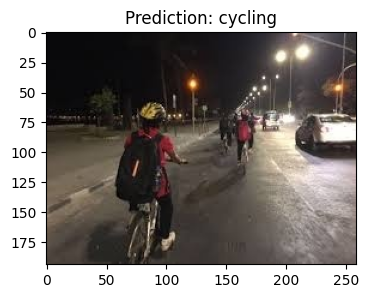

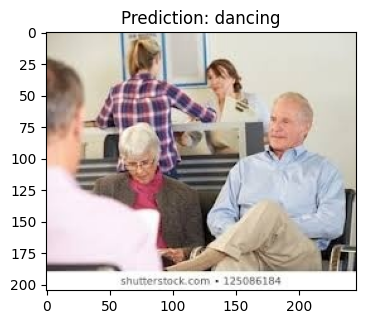

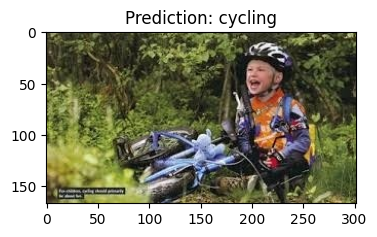

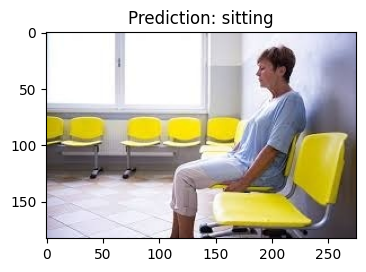

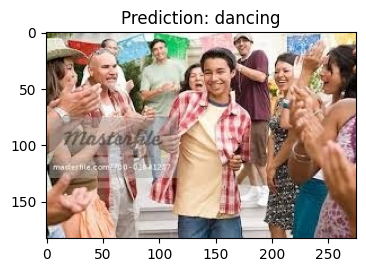

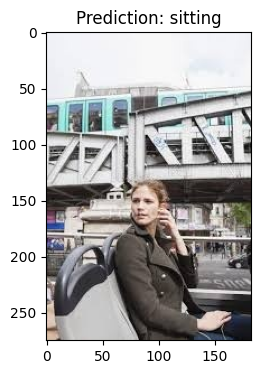

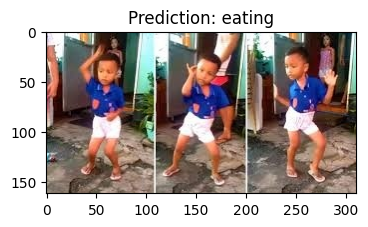

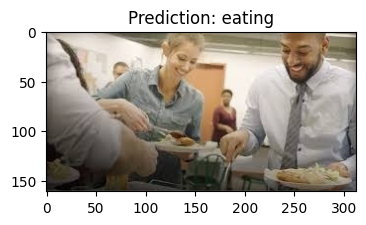

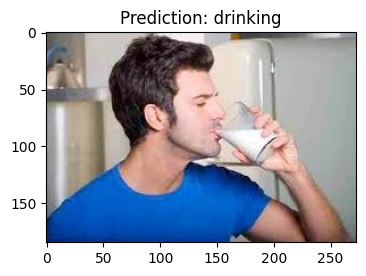

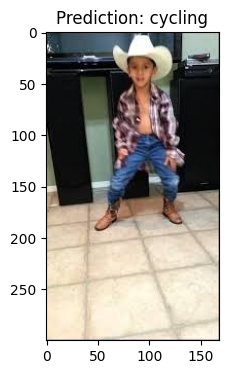

In [68]:
for idx, row in df_test.sample(10).iterrows():
    img_path = row['filename']
    image_true = Image.open(img_path)

    image = transform(image_true).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)

    predicted_class = torch.argmax(output).item()
    plt.figure(figsize=(4, 4))
    plt.imshow(image_true)
    plt.title(f'Prediction: {output_label_map[predicted_class]}')
    plt.show()


## `Epoch vs Train Loss`

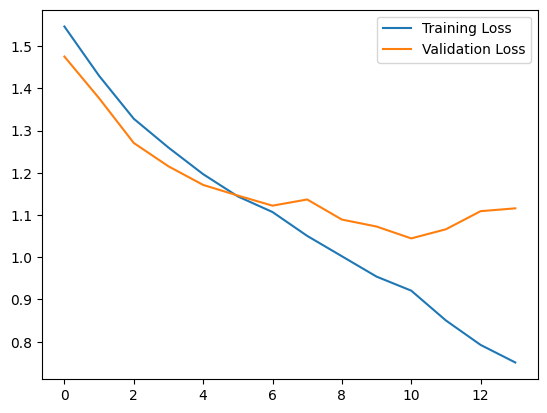

In [69]:
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Validation Loss")
plt.legend()
plt.show()